In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#declaring an object of type mnist
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

4431872/4422102 [==============================] - 0s 0us/step


training image would be a picture and the training label would be a number

this sequential has three layers in it.
Flatten takes the 28 by 28 square and turn it into a simple linear array.
The middle layer is the hidden layer. It has 128 neurons in it. 
The last layer had 10 neurons in it as the data set has 10 classes of clothing items.


In [4]:
#for 1st image in the array
index = 0

#set the number of characters per row while printing
np.set_printoptions(linewidth=320) 

#print the label and the image 
print(f'LABEL: {train_labels[index]}')
print(f'\nIMAGE PIXEL ARRAY: \n {train_images[index]}')


LABEL: 9

IMAGE PIXEL ARRAY: 
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0   0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62  54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134 144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178 107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216 216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1

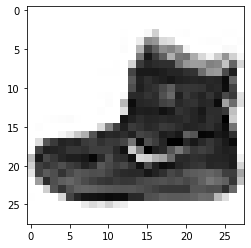

In [5]:
#visualize the image 
plt.imshow(train_images[index], cmap= 'Greys')

All the numbers in the label are between 0 to 255. For training a neural network, especially in image processing it is better to scale values between 0 to 1. This process is know as normalization.

In [6]:
train_images = train_images/255.0
test_images = test_images/255.0


In [7]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape = (28,28)),
    keras.layers.Dense(128, activation = tf.nn.relu),
    keras.layers.Dense(10,activation = tf.nn.softmax)
])

2022-04-23 20:45:36.063047: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


* Sequential: defines a sequence of layers in the neural network 
* Flatten: flatten takes the 28 by 28 square an turn it into a 1-D array
* Dense: adds a layers of neurons.
> > >  Each layer of neuron needs an activation function that tells them what to do 
* ReLu: Rectified linear unit
* if x>0:
    return x
  else: 
     return 0
* softmax: 